In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = "../data/interim/joined_data.csv"
df = pd.read_csv(path)

In [56]:
df["Date_Hour"] = pd.to_datetime(df["Date_Hour"])
df = df.set_index('Date_Hour').sort_index()

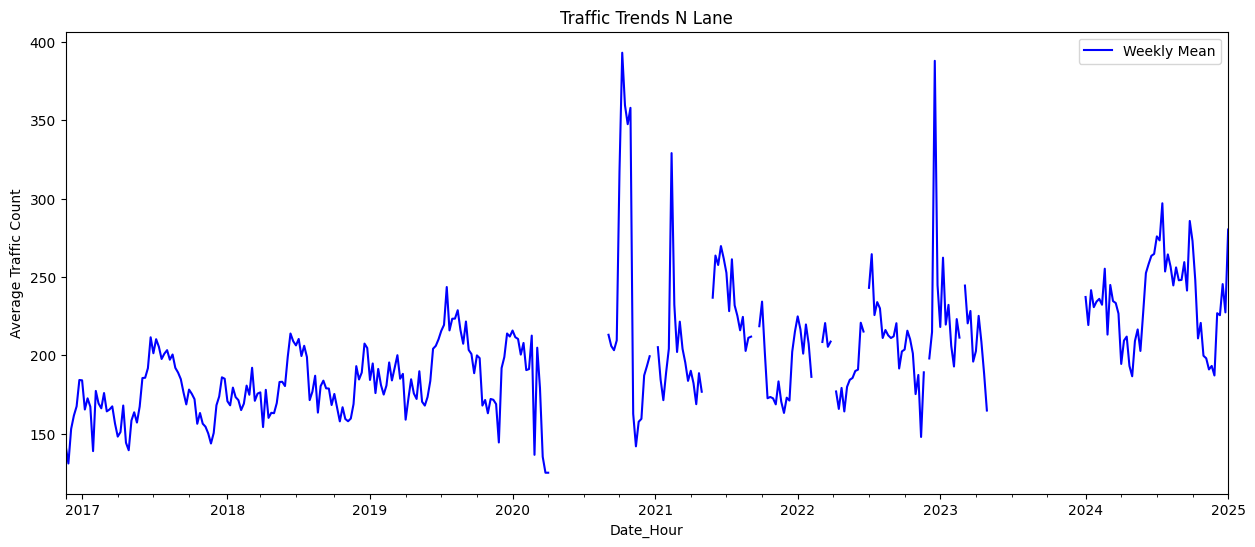

In [63]:
plt.figure(figsize=(15, 6))
df['NLane1'].resample('W').mean().plot(label='Weekly Mean', color='blue')
plt.title('Traffic Trends N Lane')
plt.ylabel('Average Traffic Count')
plt.legend()
plt.show()

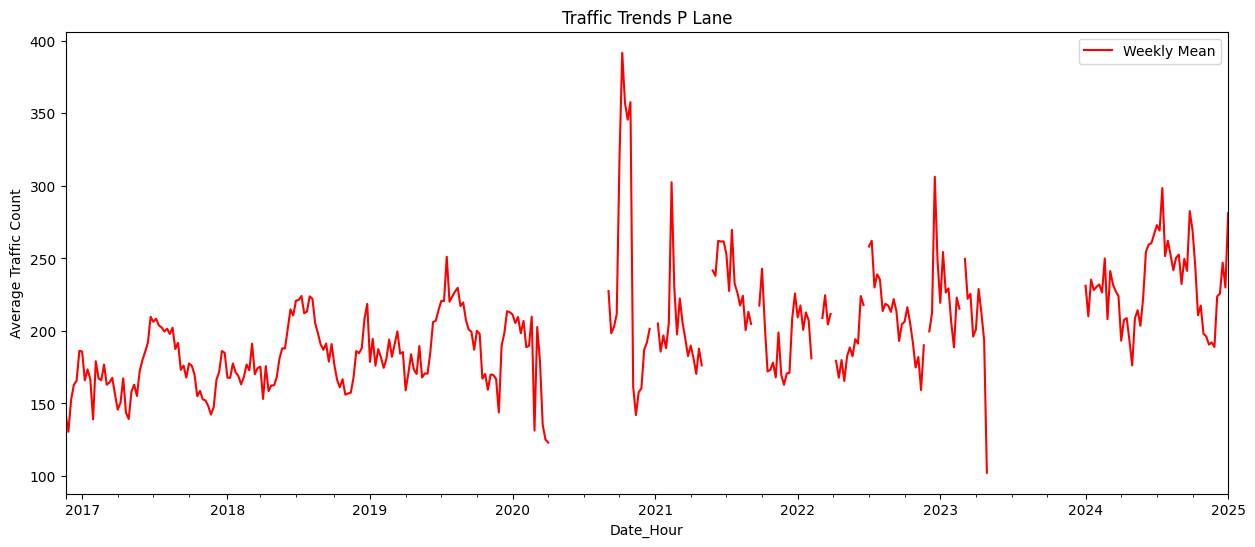

In [64]:
plt.figure(figsize=(15, 6))
df['PLane1'].resample('W').mean().plot(label='Weekly Mean', color='red')
plt.title('Traffic Trends P Lane')
plt.ylabel('Average Traffic Count')
plt.legend()
plt.show()

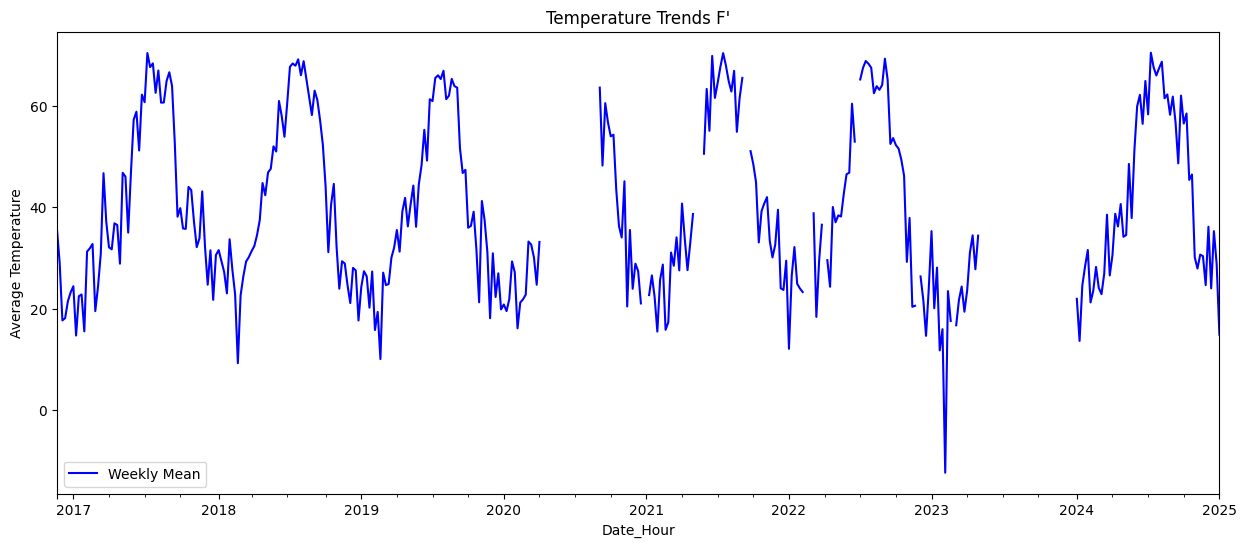

In [59]:
plt.figure(figsize=(15, 6))
df['TMP ° F'].resample('W').mean().plot(label='Weekly Mean', color='blue')
plt.title('Temperature Trends F\'')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

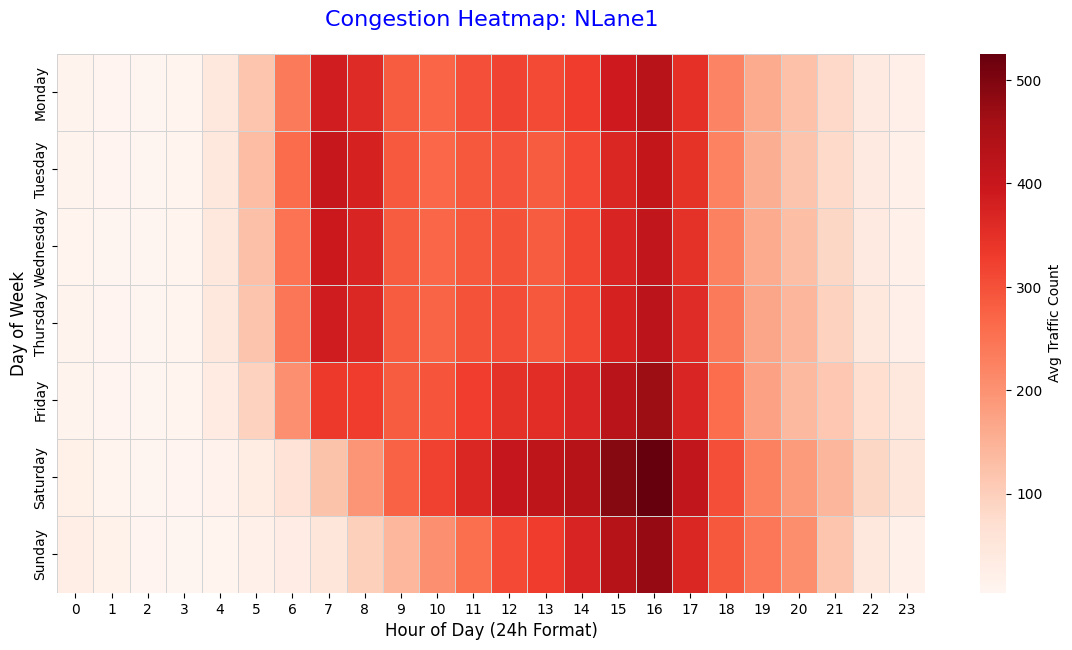

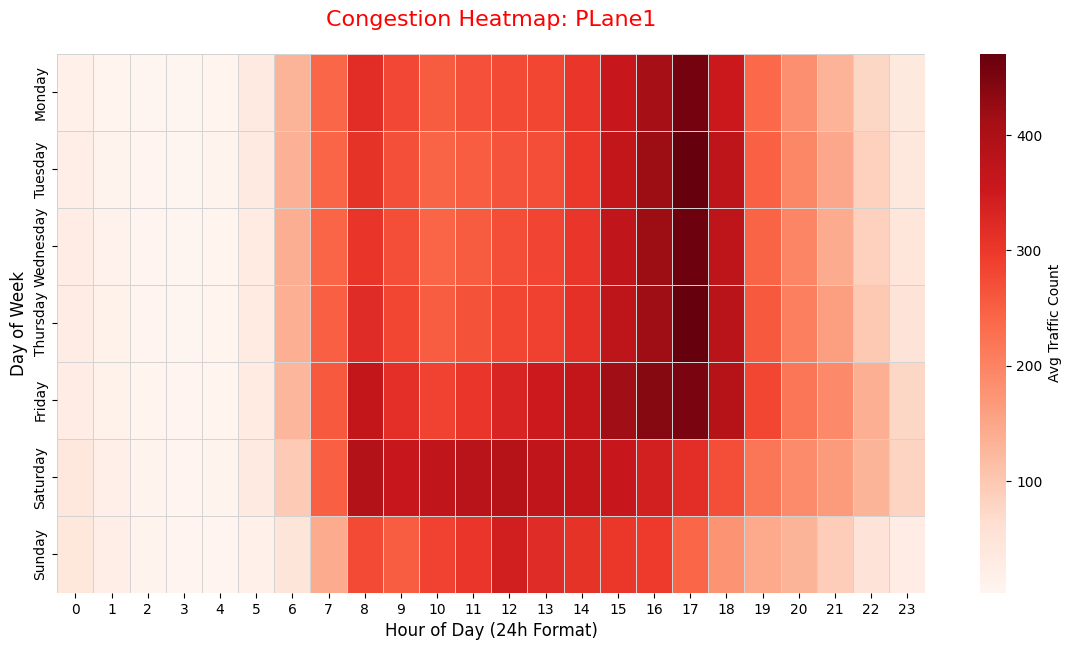

In [60]:
df['Hour'] = df.index.hour
df['Day'] = df.index.day_name()
df['Month'] = df.index.month
df['Year'] = df.index.year

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

def plot_traffic_heatmap(lane_name, title_color):
    pivot_df = df.groupby(['Day', 'Hour'])[lane_name].mean().unstack()
    pivot_df = pivot_df.reindex(days_order)

    plt.figure(figsize=(14, 7))
    sns.heatmap(pivot_df, 
                cmap="Reds", 
                linewidths=.5, 
                linecolor='lightgrey',
                cbar_kws={'label': 'Avg Traffic Count'})

    plt.title(f'Congestion Heatmap: {lane_name}', fontsize=16, pad=20, color=title_color)
    plt.xlabel('Hour of Day (24h Format)', fontsize=12)
    plt.ylabel('Day of Week', fontsize=12)
    plt.show()

plot_traffic_heatmap('NLane1', 'blue')
plot_traffic_heatmap('PLane1', 'red')